In [1]:
import pandas as pd

df = pd.read_csv("C:/Users/Sambhrama/Downloads/final_aviation_ml_dataset_deduplicated.csv")
print(df.shape)
print(df.head())

print(df['hfacs_label'].value_counts())



(17993, 4)
            ev_id  event_date  \
0  20080107X00026  2008-01-01   
1  20080107X00027  2008-01-03   
2  20080109X00036  2008-01-01   
3  20080114X00044  2008-01-06   
4  20080115X00046  2008-01-03   

                                         report_text   hfacs_label  
0  The pilots were attending a fly-in at the airp...    Unsafe Act  
1  After an uneventful landing at night, the comm...  Precondition  
2  The private pilot was conducting a touch-and-g...  Precondition  
3  According to the certified flight instructor (...    Unsafe Act  
4  While on short final approach the pilot reduce...    Unsafe Act  
Unsafe Act            15358
Precondition           2376
Unsafe Supervision      259
Name: hfacs_label, dtype: int64


In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('omw-1.4')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['report_text'].apply(clean_text)

print(df[['report_text', 'clean_text']].head())


[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Sambhrama\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sambhrama\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Sambhrama\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                         report_text  \
0  The pilots were attending a fly-in at the airp...   
1  After an uneventful landing at night, the comm...   
2  The private pilot was conducting a touch-and-g...   
3  According to the certified flight instructor (...   
4  While on short final approach the pilot reduce...   

                                          clean_text  
0  pilot attending flyin airport one pilot lowwin...  
1  uneventful landing night commercial rated pilo...  
2  private pilot conducting touchandgo tailwheele...  
3  according certified flight instructor cfi depa...  
4  short final approach pilot reduced engine powe...  


In [5]:
print(df.columns)


Index(['ev_id', 'event_date', 'report_text', 'hfacs_label', 'clean_text'], dtype='object')


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,   # limit vocabulary size (important)
    ngram_range=(1, 2)   
)

# Convert text to numeric features
X = vectorizer.fit_transform(df['clean_text'])

y = df['hfacs_label']

print("TF-IDF feature matrix shape:", X.shape)
print("Target shape:", y.shape)
vectorizer.get_feature_names_out()[:20]

TF-IDF feature matrix shape: (17993, 5000)
Target shape: (17993,)


array(['abeam', 'ability', 'able', 'able maintain', 'abnormal',
       'abnormality', 'aboard', 'abort', 'abort landing', 'abort takeoff',
       'aborted', 'aborted landing', 'aborted takeoff', 'abrupt',
       'abruptly', 'absence', 'accelerate', 'accelerated', 'accelerating',
       'acceleration'], dtype=object)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,                # TF-IDF features
    y,                # labels
    test_size=0.2,    # 20% test data
    random_state=42,  # reproducibility
    stratify=y        # keep class distribution same
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (14394, 5000)
Testing set shape: (3599, 5000)


In [22]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=5,     # K = 5 (standard choice)
    metric='cosine',
    weights='distance'# cosine similarity is best for TF-IDF
)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(y_pred_knn[:10])

['Unsafe Act' 'Unsafe Act' 'Unsafe Act' 'Unsafe Act' 'Unsafe Act'
 'Unsafe Act' 'Unsafe Act' 'Unsafe Act' 'Unsafe Act' 'Unsafe Act']


In [23]:
y_test.value_counts(normalize=True)


Unsafe Act            0.853570
Precondition          0.131981
Unsafe Supervision    0.014448
Name: hfacs_label, dtype: float64

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))


                    precision    recall  f1-score   support

      Precondition       0.54      0.32      0.40       475
        Unsafe Act       0.89      0.96      0.92      3072
Unsafe Supervision       0.15      0.04      0.06        52

          accuracy                           0.86      3599
         macro avg       0.53      0.44      0.46      3599
      weighted avg       0.83      0.86      0.84      3599



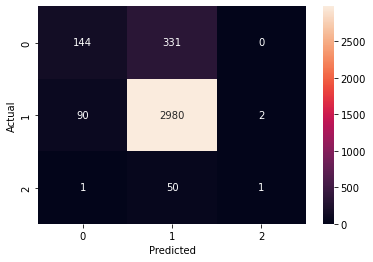

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [12]:
#comparing with random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    random_state=42,       # reproducibility
    class_weight='balanced'  # VERY IMPORTANT for your data
)



In [13]:
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [14]:
y_pred_rf=rf.predict(X_test)

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
                    precision    recall  f1-score   support

      Precondition       0.75      0.24      0.37       475
        Unsafe Act       0.88      0.99      0.93      3072
Unsafe Supervision       1.00      0.02      0.04        52

          accuracy                           0.88      3599
         macro avg       0.88      0.42      0.45      3599
      weighted avg       0.87      0.88      0.84      3599



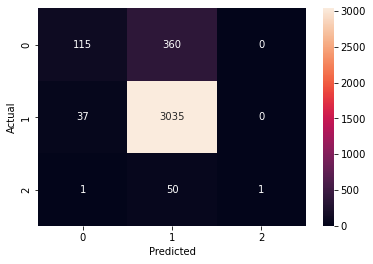

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [17]:
#extra trees
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix


et = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)

print("Extra Trees Classification Report:")
print(classification_report(y_test, y_pred_et))


Extra Trees Classification Report:
                    precision    recall  f1-score   support

      Precondition       0.71      0.25      0.37       475
        Unsafe Act       0.88      0.98      0.93      3072
Unsafe Supervision       1.00      0.02      0.04        52

          accuracy                           0.87      3599
         macro avg       0.86      0.42      0.45      3599
      weighted avg       0.86      0.87      0.84      3599



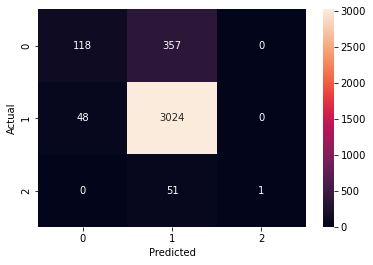

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_et)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [25]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [26]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


In [27]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [28]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)


In [29]:
xgb.fit(X_train, y_train_enc)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_class=3, num_parallel_tree=None, ...)

In [30]:
y_pred_xgb_enc = xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

print("Extra Trees Classification Report:")
print(classification_report(y_test, y_pred_et))

Extra Trees Classification Report:
                    precision    recall  f1-score   support

      Precondition       0.71      0.25      0.37       475
        Unsafe Act       0.88      0.98      0.93      3072
Unsafe Supervision       1.00      0.02      0.04        52

          accuracy                           0.87      3599
         macro avg       0.86      0.42      0.45      3599
      weighted avg       0.86      0.87      0.84      3599



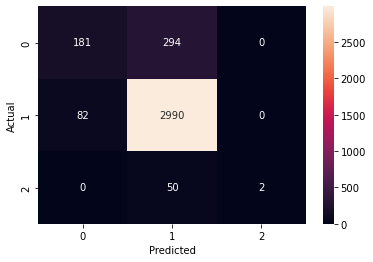

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()